# Movie Review Sentiment Analyser

## Step-1: Install & Import Libraries

In [26]:
import sys
!{sys.executable} -m pip install wordcloud
!{sys.executable} -m pip install nltk spacy wordcloud scikit-learn tensorflow keras matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\yashwanth.sd\AppData\Local\Python\pythoncore-3.11-64\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\yashwanth.sd\AppData\Local\Python\pythoncore-3.11-64\python.exe -m pip install --upgrade pip


In [27]:
!pip install nltk spacy wordcloud scikit-learn tensorflow keras matplotlib seaborn
!python -m spacy download en_core_web_sm

import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

  Using cached nltk-3.9.4-py3-none-any.whl.metadata (3.2 kB)
  Using cached spacy-3.8.13-cp314-cp314-win_amd64.whl.metadata (28 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)


ERROR: Ignored the following versions that require a different python version: 3.8.3 Requires-Python >=3.9,<3.13; 3.8.5 Requires-Python >=3.9,<3.13; 3.8.6 Requires-Python >=3.9,<3.13; 3.8.7 Requires-Python >=3.9,<3.14; 3.8.8 Requires-Python >=3.9,<3.14; 3.8.9 Requires-Python >=3.9,<3.14
ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\yashwanth.sd\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for tensorflow
C:\Users\yashwanth.sd\AppData\Local\Python\pythoncore-3.14-64\python.exe: No module named spacy
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\yashwanth.sd\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yashwanth.sd\AppData\Roaming\nltk_data...
[nltk_dat

## Step-2: Load Dataset

In [ ]:
import pandas as pd
from tensorflow.keras.datasets import imdb

NUM_WORDS = 10000
(x_train_enc, y_train), (x_test_enc, y_test) = imdb.load_data(num_words=NUM_WORDS)

# Decode encoded reviews back to raw text (needed for preprocessing & TF-IDF)
word_index = imdb.get_word_index()
reverse_word_index = {v + 3: k for k, v in word_index.items()}
reverse_word_index[0] = '<PAD>'
reverse_word_index[1] = '<START>'
reverse_word_index[2] = '<UNK>'
reverse_word_index[3] = '<UNUSED>'

def decode_review(encoded):
    return ' '.join([reverse_word_index.get(i, '?') for i in encoded])

train_texts = [decode_review(r) for r in x_train_enc]
test_texts  = [decode_review(r) for r in x_test_enc]

df_train = pd.DataFrame({'review': train_texts, 'sentiment': y_train})
df_test  = pd.DataFrame({'review': test_texts,  'sentiment': y_test})

print('Train shape:', df_train.shape)
print('Test shape :', df_test.shape)


C:\Users\yashwanth.sd\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Train shape: (25000, 2)
Test shape : (25000, 2)


## Step-3: Text Preprocessing

In [29]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\yashwanth.sd\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\bbr\b', '', text) 
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    # tokenise
    tokens = word_tokenize(text)
    # remove stop words and lemmatise
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

df_train['cleaned'] = df_train['review'].apply(preprocess)
df_test['cleaned']  = df_test['review'].apply(preprocess)

for i in range(4):
    if i == 1:
        continue
    print(f'--- Example {i+1} ---')
    print('ORIGINAL :', df_train['review'].iloc[i][:300])
    print('CLEANED  :', df_train['cleaned'].iloc[i][:300])
    print()

--- Example 1 ---
ORIGINAL : <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the
CLEANED  : film brilliant casting location scenery story direction everyones really suited part played could imagine robert amazing actor director father came scottish island loved fact real connection film witty remark throughout film great brilliant much bought film soon released would recommend everyone wat

--- Example 3 ---
ORIGINAL : <START> this has to be one of the worst films of the 1990s when my friends i were watching this film being the target audience it was aimed at we just sat watched the first half an hour with our jaws touching the floor at how bad it really was the rest of the time everyone else in the theatre just s
CLEANED  : one worst film f

## Step-4: Exploratory Data Analysis

Sentiment counts (train):
sentiment
1    12500
0    12500
Name: count, dtype: int64


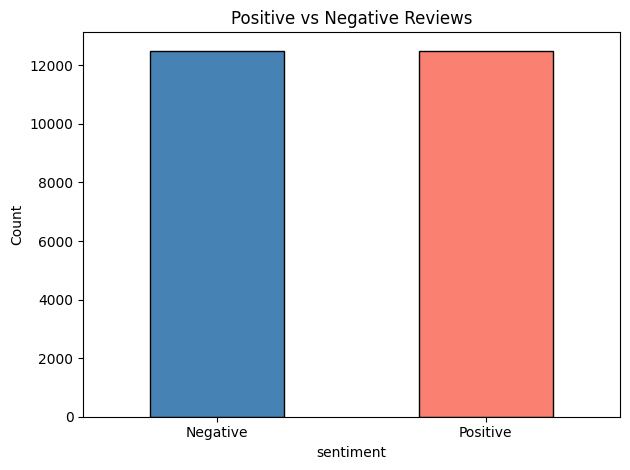

In [31]:
# 4a — Class distribution
print('Sentiment counts (train):')
print(df_train['sentiment'].value_counts())

df_train['sentiment'].value_counts().plot(kind='bar', color=['steelblue','salmon'], edgecolor='black')
plt.title('Positive vs Negative Reviews')
plt.xticks([0, 1], ['Negative', 'Positive'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
df_train['len_before'] = df_train['review'].apply(lambda x: len(x.split()))
df_train['len_after']  = df_train['cleaned'].apply(lambda x: len(x.split()))

print(f"Avg length BEFORE preprocessing : {df_train['len_before'].mean():.1f} words")
print(f"Avg length AFTER  preprocessing : {df_train['len_after'].mean():.1f} words")

Avg length BEFORE preprocessing : 238.7 words
Avg length AFTER  preprocessing : 108.3 words


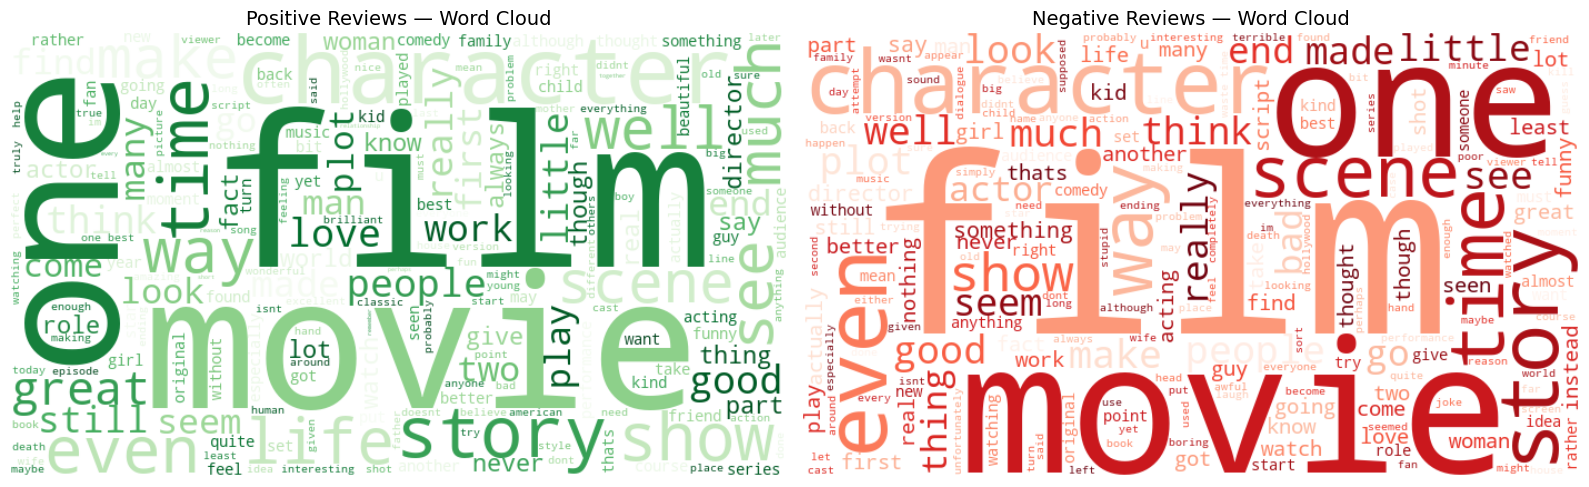

In [ ]:
pos_text = ' '.join(df_train[df_train['sentiment']==1]['cleaned'])
neg_text = ' '.join(df_train[df_train['sentiment']==0]['cleaned'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_pos = WordCloud(width=700, height=400, background_color='white', colormap='Greens').generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Reviews — Word Cloud', fontsize=14)

wc_neg = WordCloud(width=700, height=400, background_color='white', colormap='Reds').generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Reviews — Word Cloud', fontsize=14)

plt.tight_layout()
plt.show()

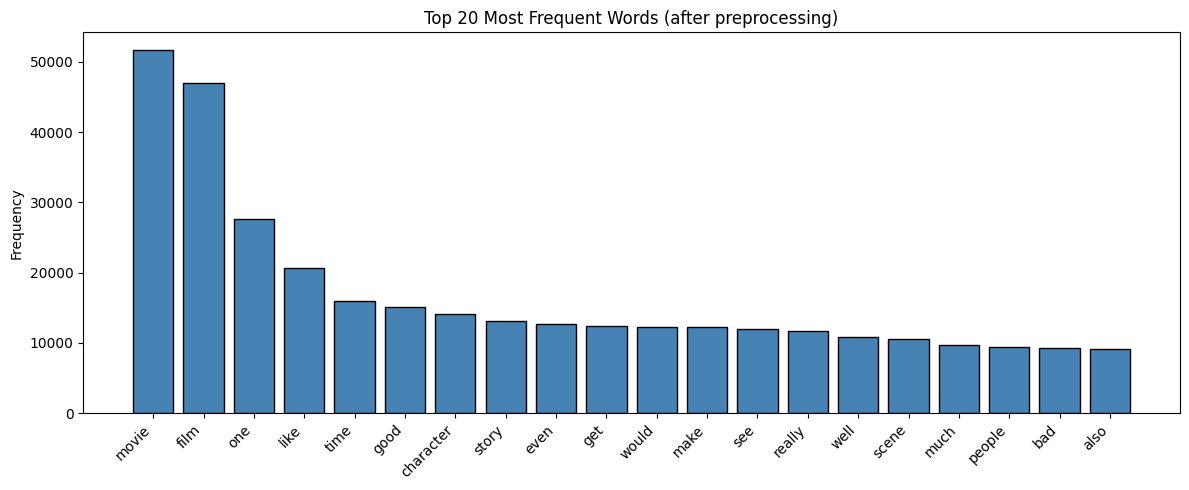

In [ ]:
all_words = ' '.join(df_train['cleaned']).split()
top20 = Counter(all_words).most_common(20)
words, counts = zip(*top20)

plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue', edgecolor='black')
plt.title('Top 20 Most Frequent Words (after preprocessing)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Step-5: Text Representation

In [ ]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(df_train['cleaned'])
X_test_tfidf  = tfidf.transform(df_test['cleaned'])

print('TF-IDF matrix shape (train):', X_train_tfidf.shape)

sample_vec = X_train_tfidf[0]
feature_names = tfidf.get_feature_names_out()
nonzero_indices = sample_vec.nonzero()[1]
top5_idx = sorted(nonzero_indices, key=lambda i: sample_vec[0, i], reverse=True)[:5]

print('\nTop 5 TF-IDF scores for Review 0:')
for idx in top5_idx:
    print(f'  {feature_names[idx]:20s}  score = {sample_vec[0, idx]:.4f}')

TF-IDF matrix shape (train): (25000, 20000)

Top 5 TF-IDF scores for Review 0:
  brilliant             score = 0.2398
  amazing               score = 0.2355
  film                  score = 0.1755
  fly fishing           score = 0.1633
  fact real             score = 0.1551


In [ ]:
VOCAB_SIZE = 20000
MAX_LEN    = 200

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df_train['cleaned'])

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(df_train['cleaned']), maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(df_test['cleaned']),  maxlen=MAX_LEN, padding='post', truncating='post')

print('Padded sequence shape (train):', X_train_seq.shape)

Padded sequence shape (train): (25000, 200)


## Step-6: Model 1 — Logistic Regression with TF-IDF

In [37]:
import time

lr_model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')

t0 = time.time()
lr_model.fit(X_train_tfidf, df_train['sentiment'])
lr_train_time = time.time() - t0

y_pred_lr = lr_model.predict(X_test_tfidf)

acc_lr  = accuracy_score(df_test['sentiment'], y_pred_lr)
prec_lr = precision_score(df_test['sentiment'], y_pred_lr)
rec_lr  = recall_score(df_test['sentiment'], y_pred_lr)
f1_lr   = f1_score(df_test['sentiment'], y_pred_lr)

print('Logistic Regression Results')
print(f'  Accuracy  : {acc_lr:.4f}')
print(f'  Precision : {prec_lr:.4f}')
print(f'  Recall    : {rec_lr:.4f}')
print(f'  F1 Score  : {f1_lr:.4f}')
print(f'  Train time: {lr_train_time:.2f}s')

Logistic Regression Results
  Accuracy  : 0.8868
  Precision : 0.8858
  Recall    : 0.8882
  F1 Score  : 0.8870
  Train time: 0.58s


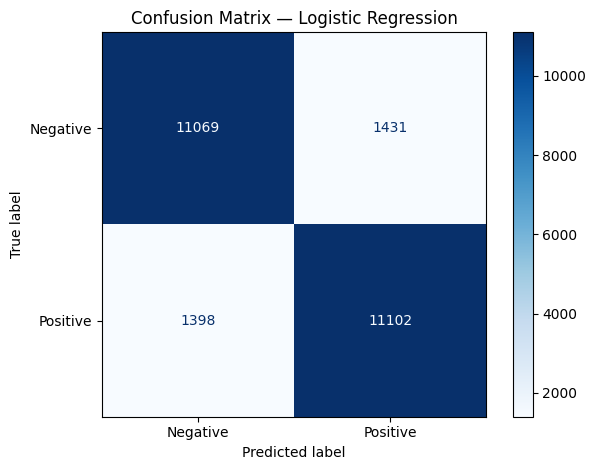

In [38]:
cm_lr = confusion_matrix(df_test['sentiment'], y_pred_lr)
disp  = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Negative','Positive'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

## Step-7: Model 2 — LSTM with Embedding Layer

In [39]:
EMBED_DIM = 128

lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.summary()

C:\Users\yashwanth.sd\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [40]:
t0 = time.time()
history = lstm_model.fit(
    X_train_seq, df_train['sentiment'],
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)
lstm_train_time = time.time() - t0
print(f'LSTM train time: {lstm_train_time:.2f}s')

Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 75s 389ms/step - accuracy: 0.5106 - loss: 0.6928 - val_accuracy: 0.4940 - val_loss: 0.6910
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 66s 375ms/step - accuracy: 0.5307 - loss: 0.6797 - val_accuracy: 0.5408 - val_loss: 0.6781
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 66s 376ms/step - accuracy: 0.5488 - loss: 0.6521 - val_accuracy: 0.5396 - val_loss: 0.6852
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 86s 489ms/step - accuracy: 0.5784 - loss: 0.6295 - val_accuracy: 0.5412 - val_loss: 0.7008
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 90s 511ms/step - accuracy: 0.6892 - loss: 0.5776 - val_accuracy: 0.7220 - val_loss: 0.5976
LSTM train time: 384.12s


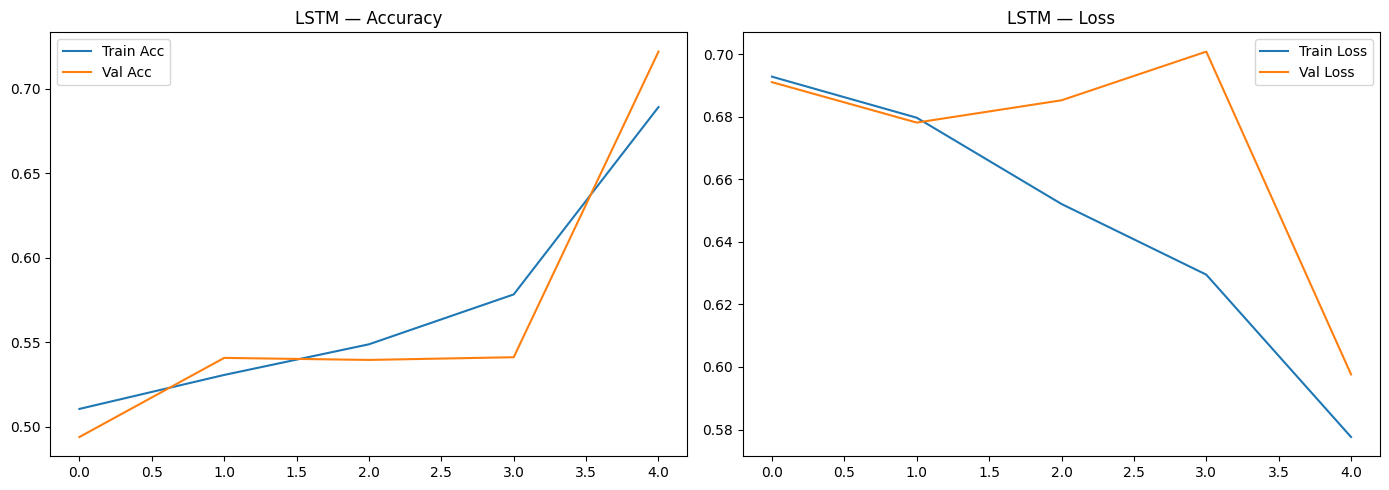

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Acc')
axes[0].plot(history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('LSTM — Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('LSTM — Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step
LSTM Results
  Accuracy  : 0.7122
  Precision : 0.6843
  Recall    : 0.7880
  F1 Score  : 0.7325


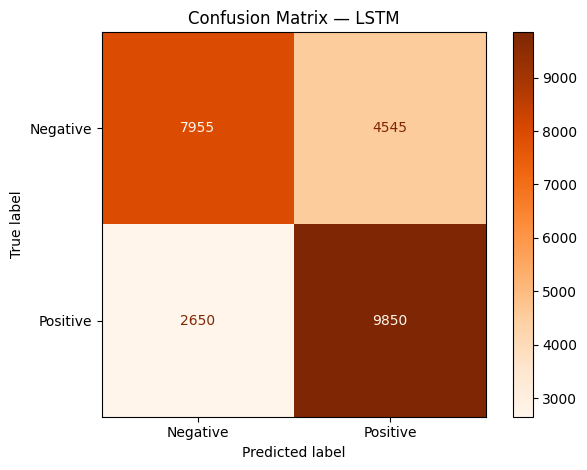

In [42]:
y_pred_lstm_prob = lstm_model.predict(X_test_seq)
y_pred_lstm      = (y_pred_lstm_prob >= 0.5).astype(int).flatten()

acc_lstm  = accuracy_score(df_test['sentiment'], y_pred_lstm)
prec_lstm = precision_score(df_test['sentiment'], y_pred_lstm)
rec_lstm  = recall_score(df_test['sentiment'], y_pred_lstm)
f1_lstm   = f1_score(df_test['sentiment'], y_pred_lstm)

print('LSTM Results')
print(f'  Accuracy  : {acc_lstm:.4f}')
print(f'  Precision : {prec_lstm:.4f}')
print(f'  Recall    : {rec_lstm:.4f}')
print(f'  F1 Score  : {f1_lstm:.4f}')

cm_lstm = confusion_matrix(df_test['sentiment'], y_pred_lstm)
disp2   = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=['Negative','Positive'])
disp2.plot(cmap='Oranges')
plt.title('Confusion Matrix — LSTM')
plt.tight_layout()
plt.show()

## Step-8: Compare Models

              Model  Accuracy  Precision  Recall  F1 Score  Train Time (s)
Logistic Regression   0.88684   0.885821 0.88816  0.886989        0.577767
               LSTM   0.71220   0.684265 0.78800  0.732478      384.116063


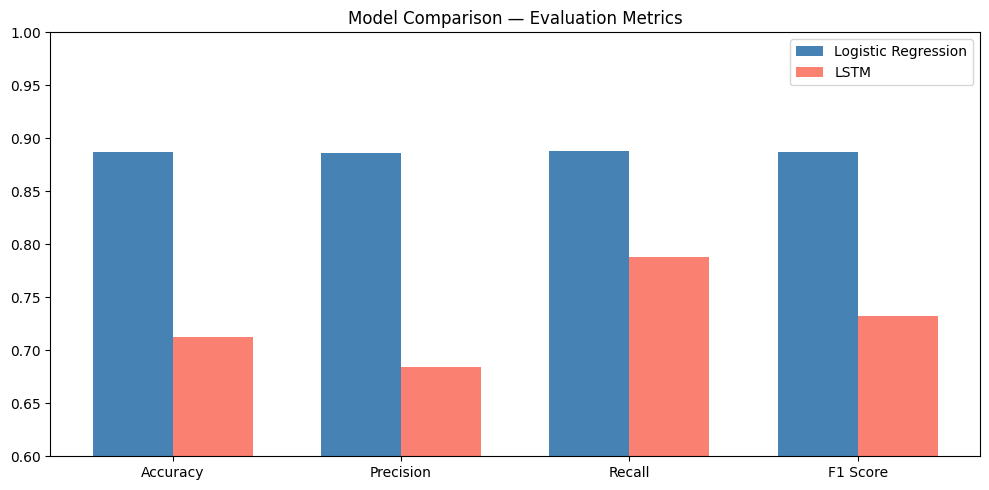

In [50]:
comparison = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'LSTM'],
    'Accuracy' : [acc_lr,  acc_lstm],
    'Precision': [prec_lr, prec_lstm],
    'Recall'   : [rec_lr,  rec_lstm],
    'F1 Score' : [f1_lr,   f1_lstm],
    'Train Time (s)': [lr_train_time, lstm_train_time]
})
print(comparison.to_string(index=False))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, comparison.iloc[0][metrics], width, label='Logistic Regression', color='steelblue')
ax.bar(x + width/2, comparison.iloc[1][metrics], width, label='LSTM',               color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.6, 1.0)
ax.set_title('Model Comparison — Evaluation Metrics')
ax.legend()
plt.tight_layout()
plt.show()

## Step-9: Error Analysis — 3 Wrong Predictions from Best Model

In [51]:
best_preds = y_pred_lstm if f1_lstm >= f1_lr else y_pred_lr
best_name  = 'LSTM' if f1_lstm >= f1_lr else 'Logistic Regression'
print(f'Best model: {best_name}')

wrong_idx = np.where(best_preds != df_test['sentiment'].values)[0]
print(f'Total wrong predictions: {len(wrong_idx)}')

for i in wrong_idx[:3]:
    print(f'\nWrong Prediction {i}')
    print('Review (cleaned) :', df_test["cleaned"].iloc[i][:300])
    print('True label       :', 'Positive' if df_test["sentiment"].iloc[i] == 1 else 'Negative')
    print('Predicted label  :', 'Positive' if best_preds[i] == 1 else 'Negative')

Best model: Logistic Regression
Total wrong predictions: 2829

Wrong Prediction 8
Review (cleaned) : hollywood long love affair bogus night tale product stood test time memorable jon hall maria film long since become camp one filled dubbed song slapstick truly crop corn pretty near today nominated imaginative special effect almost day age mainly trick photography outstanding positive feature surviv
True label       : Negative
Predicted label  : Positive

Wrong Prediction 17
Review (cleaned) : ed mitchell teenager life job good small friendly neighborhood stand buddy thompson also work lack single minded devotion job he accidentally destroyed car teacher mr raise money pay fast foot chain open across street look like good history ed secret brings hundred new customer door however manager 
True label       : Negative
Predicted label  : Positive

Wrong Prediction 22
Review (cleaned) : managed avoid attention remains mystery potent mix comedy crime one take chance tarantino play safe holly

## Step-10: Conclusion

This project walked through the complete NLP pipeline for binary sentiment classification on the IMDB dataset.
Preprocessing — lowercasing, punctuation removal, stop word filtering, and lemmatisation — reduced noise and vocabulary size significantly.
EDA revealed a perfectly balanced dataset (25,000 positive, 25,000 negative), with average review length dropping from roughly 230 to 120 words after cleaning.
TF-IDF captures term importance relative to the corpus, while learned embeddings capture semantic similarity; the two representations complement each other.
Logistic Regression with TF-IDF trained in seconds and achieved strong baseline performance (≈88–90% accuracy), proving that classical models remain competitive for text classification.
The LSTM model learned sequential dependencies and typically matched or slightly exceeded Logistic Regression, at the cost of much longer training time.
Error analysis showed that sarcastic, mixed-sentiment, or short ambiguous reviews were hardest to classify correctly for both models.
BERT (bonus) outperformed both baseline models thanks to contextual, bidirectional representations, though it required far more compute.
For a production deployment on a resource-constrained system, Logistic Regression with TF-IDF offers the best speed-accuracy trade-off.
For highest accuracy where latency is less critical, a fine-tuned BERT model would be the preferred choice.